# All-sector baseline: market information and news sentiment

## tl;dr

This notebook applies the XLK baseline methodology independently to all eleven S&P 500 SPDR sector ETFs. It compares a market-only model, a market-plus-RavenPack-news model, and an always-up reference across expanding-window 2022–2025 holdouts.

Across the eleven sectors, the market-only model averaged AUC-ROC 0.499 and the market-plus-news model averaged 0.502, a descriptive change of +0.002. News produced positive mean AUC lift in 6 of 11 sectors, led by XLF (+0.023) and XLI (+0.021), but the news model beat the always-up accuracy reference in only 4 of 11 sectors. The evidence is mixed across sectors and years rather than a stable market-wide improvement.

This is a descriptive research baseline, not a causal estimate, trading strategy, or investment recommendation.

## Context & Methods

### Research question

Does daily RavenPack news sentiment improve next-session directional prediction for any S&P 500 sector ETF beyond recent sector returns, volatility, and volume?

### Key assumptions

- The target is `fwd_1d_positive`, calculated from the next available trading session within each ETF.
- News is aggregated to `session_date` using the upstream 4:00 PM Eastern cutoff and next-session alignment.
- Every ETF is trained separately. Rows from one sector never enter another sector's model.
- Each test year is evaluated only after training on earlier dates. Feature scaling uses training-fold statistics only.
- AUC measures ranking ability. F1 and directional accuracy use a fixed 0.50 probability threshold.
- Differences across sectors and years are descriptive; no statistical-significance or transaction-cost analysis is performed.

In [1]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR",
    str(Path(tempfile.gettempdir()) / "siads699-matplotlib"),
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "data_collection").exists():
    if (REPO_ROOT.parent / "data_collection").exists():
        REPO_ROOT = REPO_ROOT.parent
    else:
        raise FileNotFoundError(
            "Run this notebook from the repository root or data_collection/."
        )

DATA_DIR = REPO_ROOT / "data_collection"
OUTPUT_DIR = REPO_ROOT / "model_outputs"
MARKET_PATH = DATA_DIR / "market_daily_df.csv"
NEWS_PATH = DATA_DIR / "news_daily_df.csv"
METRICS_PATH = OUTPUT_DIR / "sector_walk_forward_metrics.csv"
PREDICTIONS_PATH = OUTPUT_DIR / "sector_holdout_predictions.csv"
SUMMARY_PATH = OUTPUT_DIR / "sector_model_summary.csv"
FIGURE_PATH = OUTPUT_DIR / "sector_baseline_visual_summary.png"

SECTOR_NAMES = {
    "XLK": "Technology",
    "XLV": "Health Care",
    "XLF": "Financials",
    "XLC": "Communication Services",
    "XLY": "Consumer Discretionary",
    "XLI": "Industrials",
    "XLP": "Consumer Staples",
    "XLE": "Energy",
    "XLU": "Utilities",
    "XLB": "Materials",
    "XLRE": "Real Estate",
}
SECTOR_TICKERS = list(SECTOR_NAMES)
START_DATE = pd.Timestamp("2020-01-01")
END_DATE = pd.Timestamp("2025-12-31")
TEST_YEARS = [2022, 2023, 2024, 2025]

BASELINE_FEATURES = [
    "return_lag_1",
    "return_lag_5",
    "return_lag_20",
    "return_mean_5",
    "return_mean_20",
    "return_std_20",
    "volume_log_lag_1",
]
SENTIMENT_FEATURES = [
    "mean_event_sentiment_score",
    "positive_event_share",
    "negative_event_share",
    "news_volume_log",
    "source_count_log",
]

MODEL_MARKET = "Market-only model"
MODEL_NEWS = "Market + news sentiment model"
MODEL_REFERENCE = "Always-up reference"

print(f"Project folder: {REPO_ROOT}")
print(f"Sector market data: {MARKET_PATH}")
print(f"RavenPack daily news: {NEWS_PATH}")
print(f"Sectors: {len(SECTOR_TICKERS)}; holdout years: {TEST_YEARS}")

Project folder: /workspace/scratch/7aedacb68f09
Sector market data: /workspace/scratch/7aedacb68f09/data_collection/market_daily_df.csv
RavenPack daily news: /workspace/scratch/7aedacb68f09/data_collection/news_daily_df.csv
Sectors: 11; holdout years: [2022, 2023, 2024, 2025]


## Data

### 1. Load and validate the sector and news panels

The market file is the engineered CRSP sector-ETF table produced upstream. The news file contains daily RavenPack macro-event aggregates. The checks below enforce the complete sector universe, one row per sector-session, one row per news session, and the next-session target definition.

In [2]:
required_market_columns = {
    "session_date", "ticker", "daily_return", "price", "volume",
    "fwd_1d_return", "fwd_1d_positive",
}
required_news_columns = {
    "session_date", "event_record_count", "unique_source_count",
    "mean_event_sentiment_score", "positive_event_share",
    "negative_event_share",
}

market_all = pd.read_csv(MARKET_PATH, parse_dates=["session_date"])
news_all = pd.read_csv(NEWS_PATH, parse_dates=["session_date"])

market_missing = required_market_columns - set(market_all.columns)
news_missing = required_news_columns - set(news_all.columns)
if market_missing:
    raise ValueError(f"Market table is missing: {sorted(market_missing)}")
if news_missing:
    raise ValueError(f"News table is missing: {sorted(news_missing)}")

market = market_all.loc[
    market_all["ticker"].isin(SECTOR_TICKERS)
    & market_all["session_date"].between(START_DATE, END_DATE)
].copy()
found_tickers = set(market["ticker"].unique())
missing_tickers = set(SECTOR_TICKERS) - found_tickers
unexpected_tickers = found_tickers - set(SECTOR_TICKERS)
if missing_tickers or unexpected_tickers:
    raise ValueError(
        f"Ticker-universe mismatch; missing={sorted(missing_tickers)}, "
        f"unexpected={sorted(unexpected_tickers)}"
    )

duplicate_market_rows = int(
    market.duplicated(["ticker", "session_date"]).sum()
)
if duplicate_market_rows:
    raise ValueError(
        f"Duplicate ticker-session market rows: {duplicate_market_rows}"
    )
market = market.sort_values(["ticker", "session_date"]).reset_index(drop=True)

market["next_daily_return"] = market.groupby("ticker")["daily_return"].shift(-1)
return_check = market[["fwd_1d_return", "next_daily_return"]].dropna()
if not np.allclose(
    return_check["fwd_1d_return"],
    return_check["next_daily_return"],
    atol=1e-12,
):
    raise ValueError("The one-session forward-return check failed.")
market = market.drop(columns="next_daily_return")

news = news_all.loc[
    news_all["session_date"].between(START_DATE, END_DATE)
].copy()
duplicate_news_dates = int(news.duplicated("session_date").sum())
if duplicate_news_dates:
    raise ValueError(f"Duplicate news session dates: {duplicate_news_dates}")
news = news.sort_values("session_date").reset_index(drop=True)

coverage = (
    market.groupby("ticker")["session_date"]
    .agg(first_session="min", last_session="max", rows="size")
    .reindex(SECTOR_TICKERS)
)
print(f"Market rows: {len(market):,}; news sessions: {len(news):,}")
display(coverage)

Market rows: 16,588; news sessions: 1,508


,first_session,last_session,rows
ticker,,,
XLK,2020-01-02,2025-12-31,1508
XLV,2020-01-02,2025-12-31,1508
XLF,2020-01-02,2025-12-31,1508
XLC,2020-01-02,2025-12-31,1508
XLY,2020-01-02,2025-12-31,1508
XLI,2020-01-02,2025-12-31,1508
XLP,2020-01-02,2025-12-31,1508
XLE,2020-01-02,2025-12-31,1508
XLU,2020-01-02,2025-12-31,1508


### 2. Engineer lagged market and daily news features

All return and volume features are shifted within ticker before rolling calculations. The shared daily news aggregates are joined after market validation.

In [3]:
panel = market.merge(news, on="session_date", how="left", validate="many_to_one")
panel = panel.sort_values(["ticker", "session_date"]).reset_index(drop=True)

grouped_returns = panel.groupby("ticker")["daily_return"]
for lag in [1, 5, 20]:
    panel[f"return_lag_{lag}"] = grouped_returns.shift(lag)
panel["return_mean_5"] = grouped_returns.transform(
    lambda values: values.shift(1).rolling(5, min_periods=5).mean()
)
panel["return_mean_20"] = grouped_returns.transform(
    lambda values: values.shift(1).rolling(20, min_periods=20).mean()
)
panel["return_std_20"] = grouped_returns.transform(
    lambda values: values.shift(1).rolling(20, min_periods=20).std(ddof=0)
)

panel["volume_log"] = np.log1p(panel["volume"].clip(lower=0))
panel["volume_log_lag_1"] = panel.groupby("ticker")["volume_log"].shift(1)
panel["news_volume_log"] = np.log1p(
    panel["event_record_count"].clip(lower=0)
)
panel["source_count_log"] = np.log1p(
    panel["unique_source_count"].clip(lower=0)
)

required_model_columns = (
    BASELINE_FEATURES + SENTIMENT_FEATURES + ["fwd_1d_positive"]
)
panel = panel.dropna(subset=required_model_columns).copy()
panel["target"] = panel["fwd_1d_positive"].astype(int)

usable_rows = panel.groupby("ticker").size().reindex(SECTOR_TICKERS)
if usable_rows.isna().any() or (usable_rows == 0).any():
    raise ValueError("At least one sector has no usable modeling rows.")

print(f"Rows ready for modeling: {len(panel):,}")
modeling_coverage = pd.DataFrame(
    {
        "usable_rows": usable_rows,
        "positive_label_rate": (
            panel.groupby("ticker")["target"].mean().reindex(SECTOR_TICKERS)
        ),
    }
)
modeling_coverage["positive_label_rate"] = modeling_coverage[
    "positive_label_rate"
].map(lambda value: f"{value:.1%}")
display(modeling_coverage)

Rows ready for modeling: 16,357


,usable_rows,positive_label_rate
ticker,,
XLK,1487,55.3%
XLV,1487,52.0%
XLF,1487,52.5%
XLC,1487,54.8%
XLY,1487,54.3%
XLI,1487,53.5%
XLP,1487,52.0%
XLE,1487,53.3%
XLU,1487,52.7%


### 3. Define the evaluation functions

The optimizer and metrics match the XLK notebook: a small L2-regularized logistic regression implemented in NumPy, training-only standardization, rank-based AUC, and threshold-based F1 and accuracy.

In [4]:
def sigmoid(values: np.ndarray) -> np.ndarray:
    clipped = np.clip(values, -35.0, 35.0)
    return 1.0 / (1.0 + np.exp(-clipped))


def fit_logistic(
    x_train: np.ndarray,
    y_train: np.ndarray,
    learning_rate: float = 0.08,
    iterations: int = 2500,
    l2: float = 0.05,
) -> tuple[np.ndarray, float]:
    weights = np.zeros(x_train.shape[1], dtype=float)
    intercept = 0.0
    n_rows = float(len(y_train))
    for _ in range(iterations):
        probabilities = sigmoid(x_train @ weights + intercept)
        residual = probabilities - y_train
        weights -= learning_rate * (
            (x_train.T @ residual) / n_rows + l2 * weights
        )
        intercept -= learning_rate * residual.mean()
    return weights, intercept


def standardize(
    x_train: pd.DataFrame, x_test: pd.DataFrame
) -> tuple[np.ndarray, np.ndarray]:
    train_mean = x_train.mean(axis=0)
    train_std = x_train.std(axis=0, ddof=0).replace(0.0, 1.0)
    train_scaled = ((x_train - train_mean) / train_std).to_numpy(
        dtype=float
    )
    test_scaled = ((x_test - train_mean) / train_std).to_numpy(
        dtype=float
    )
    return train_scaled, test_scaled


def roc_auc(y_true: np.ndarray, scores: np.ndarray) -> float:
    positives = y_true == 1
    negatives = y_true == 0
    n_positive = int(positives.sum())
    n_negative = int(negatives.sum())
    if n_positive == 0 or n_negative == 0:
        return float("nan")

    order = np.argsort(scores, kind="mergesort")
    sorted_scores = scores[order]
    ranks = np.empty(len(scores), dtype=float)
    start = 0
    while start < len(scores):
        end = start + 1
        while (
            end < len(scores)
            and sorted_scores[end] == sorted_scores[start]
        ):
            end += 1
        ranks[order[start:end]] = (start + 1 + end) / 2.0
        start = end

    positive_rank_sum = ranks[positives].sum()
    return float(
        (
            positive_rank_sum
            - n_positive * (n_positive + 1) / 2.0
        )
        / (n_positive * n_negative)
    )


def classification_metrics(
    y_true: np.ndarray, probabilities: np.ndarray
) -> dict[str, float]:
    predictions = (probabilities >= 0.5).astype(int)
    true_positive = int(
        ((predictions == 1) & (y_true == 1)).sum()
    )
    false_positive = int(
        ((predictions == 1) & (y_true == 0)).sum()
    )
    false_negative = int(
        ((predictions == 0) & (y_true == 1)).sum()
    )
    denominator = 2 * true_positive + false_positive + false_negative
    f1 = (
        0.0
        if denominator == 0
        else 2.0 * true_positive / denominator
    )
    return {
        "auc_roc": roc_auc(y_true, probabilities),
        "f1": float(f1),
        "directional_accuracy": float(
            (predictions == y_true).mean()
        ),
    }

## Results

### 4. Run independent chronological holdouts

Each ETF receives its own expanding-window model for every test year. The always-up reference is evaluated on the same holdout observations.

In [5]:
model_features = {
    MODEL_MARKET: BASELINE_FEATURES,
    MODEL_NEWS: BASELINE_FEATURES + SENTIMENT_FEATURES,
}
metric_rows = []
prediction_rows = []

for ticker in SECTOR_TICKERS:
    sector_panel = panel.loc[panel["ticker"].eq(ticker)].copy()
    for test_year in TEST_YEARS:
        train = sector_panel.loc[
            sector_panel["session_date"]
            < pd.Timestamp(f"{test_year}-01-01")
        ]
        test = sector_panel.loc[
            sector_panel["session_date"].dt.year.eq(test_year)
        ]
        if train.empty or test.empty:
            raise ValueError(
                f"{ticker} {test_year} has train={len(train)}, "
                f"test={len(test)}."
            )

        y_train = train["target"].to_numpy(dtype=int)
        y_test = test["target"].to_numpy(dtype=int)

        for model_name, feature_columns in model_features.items():
            x_train, x_test = standardize(
                train[feature_columns], test[feature_columns]
            )
            weights, intercept = fit_logistic(x_train, y_train)
            probabilities = sigmoid(x_test @ weights + intercept)
            metrics = classification_metrics(y_test, probabilities)

            for metric_name, score in metrics.items():
                metric_rows.append(
                    {
                        "ticker": ticker,
                        "sector": SECTOR_NAMES[ticker],
                        "model": model_name,
                        "fold": test_year,
                        "metric": metric_name,
                        "score": score,
                    }
                )

            predictions = (probabilities >= 0.5).astype(int)
            for row, probability, prediction in zip(
                test.itertuples(index=False),
                probabilities,
                predictions,
            ):
                prediction_rows.append(
                    {
                        "ticker": ticker,
                        "sector": SECTOR_NAMES[ticker],
                        "model": model_name,
                        "fold": test_year,
                        "session_date": row.session_date.date().isoformat(),
                        "y_true": int(row.target),
                        "y_pred": int(prediction),
                        "y_prob": float(probability),
                    }
                )

        reference_probabilities = np.ones(len(test), dtype=float)
        reference_metrics = classification_metrics(
            y_test, reference_probabilities
        )
        for metric_name, score in reference_metrics.items():
            metric_rows.append(
                {
                    "ticker": ticker,
                    "sector": SECTOR_NAMES[ticker],
                    "model": MODEL_REFERENCE,
                    "fold": test_year,
                    "metric": metric_name,
                    "score": score,
                }
            )
        for row in test.itertuples(index=False):
            prediction_rows.append(
                {
                    "ticker": ticker,
                    "sector": SECTOR_NAMES[ticker],
                    "model": MODEL_REFERENCE,
                    "fold": test_year,
                    "session_date": row.session_date.date().isoformat(),
                    "y_true": int(row.target),
                    "y_pred": 1,
                    "y_prob": 1.0,
                }
            )

    print(f"Completed {ticker}: {SECTOR_NAMES[ticker]}")

metrics_df = pd.DataFrame(metric_rows)
predictions_df = pd.DataFrame(prediction_rows)
expected_metric_rows = (
    len(SECTOR_TICKERS)
    * len(TEST_YEARS)
    * 3
    * 3
)
if len(metrics_df) != expected_metric_rows:
    raise ValueError(
        f"Expected {expected_metric_rows} metric rows; "
        f"found {len(metrics_df)}."
    )
if not metrics_df["score"].between(0, 1).all():
    raise ValueError("At least one evaluation score is outside [0, 1].")
if metrics_df["score"].isna().any():
    raise ValueError("At least one evaluation score is missing.")
if predictions_df.duplicated(
    ["ticker", "model", "fold", "session_date"]
).any():
    raise ValueError("Prediction keys are not unique.")

OUTPUT_DIR.mkdir(exist_ok=True)
metrics_df.to_csv(METRICS_PATH, index=False)
predictions_df.to_csv(PREDICTIONS_PATH, index=False)
print(f"Wrote {METRICS_PATH.relative_to(REPO_ROOT)}")
print(f"Wrote {PREDICTIONS_PATH.relative_to(REPO_ROOT)}")

Completed XLK: Technology
Completed XLV: Health Care
Completed XLF: Financials
Completed XLC: Communication Services
Completed XLY: Consumer Discretionary
Completed XLI: Industrials
Completed XLP: Consumer Staples
Completed XLE: Energy
Completed XLU: Utilities
Completed XLB: Materials
Completed XLRE: Real Estate
Wrote model_outputs/sector_walk_forward_metrics.csv
Wrote model_outputs/sector_holdout_predictions.csv


### 5. Summarize cross-sector performance

Fold-level metrics remain available in the long output table. This compact table averages the four holdout years and reports the fitted news model's change relative to the market-only model.

In [6]:
mean_metrics = (
    metrics_df.groupby(["ticker", "sector", "model", "metric"])["score"]
    .agg(["mean", "std", "count"])
    .reset_index()
)
mean_wide = mean_metrics.pivot(
    index=["ticker", "sector"],
    columns=["model", "metric"],
    values="mean",
)

fold_auc = metrics_df.loc[metrics_df["metric"].eq("auc_roc")].pivot(
    index=["ticker", "fold"],
    columns="model",
    values="score",
)
fold_auc["auc_lift"] = fold_auc[MODEL_NEWS] - fold_auc[MODEL_MARKET]
auc_wins = (
    fold_auc["auc_lift"].gt(0).groupby("ticker").sum().astype(int)
)

summary_rows = []
for ticker in SECTOR_TICKERS:
    key = (ticker, SECTOR_NAMES[ticker])
    market_auc = float(mean_wide.loc[key, (MODEL_MARKET, "auc_roc")])
    news_auc = float(mean_wide.loc[key, (MODEL_NEWS, "auc_roc")])
    market_accuracy = float(
        mean_wide.loc[key, (MODEL_MARKET, "directional_accuracy")]
    )
    news_accuracy = float(
        mean_wide.loc[key, (MODEL_NEWS, "directional_accuracy")]
    )
    reference_accuracy = float(
        mean_wide.loc[key, (MODEL_REFERENCE, "directional_accuracy")]
    )
    summary_rows.append(
        {
            "ticker": ticker,
            "sector": SECTOR_NAMES[ticker],
            "market_auc": market_auc,
            "news_auc": news_auc,
            "auc_lift": news_auc - market_auc,
            "market_accuracy": market_accuracy,
            "news_accuracy": news_accuracy,
            "reference_accuracy": reference_accuracy,
            "accuracy_lift": news_accuracy - market_accuracy,
            "market_f1": float(
                mean_wide.loc[key, (MODEL_MARKET, "f1")]
            ),
            "news_f1": float(mean_wide.loc[key, (MODEL_NEWS, "f1")]),
            "reference_f1": float(
                mean_wide.loc[key, (MODEL_REFERENCE, "f1")]
            ),
            "news_auc_wins": int(auc_wins.loc[ticker]),
            "folds": len(TEST_YEARS),
        }
    )

sector_summary = (
    pd.DataFrame(summary_rows)
    .sort_values(["auc_lift", "ticker"], ascending=[False, True])
    .reset_index(drop=True)
)
sector_summary.to_csv(SUMMARY_PATH, index=False)

summary_display = sector_summary[
    [
        "ticker", "sector", "market_auc", "news_auc", "auc_lift",
        "market_accuracy", "news_accuracy", "reference_accuracy",
        "accuracy_lift", "news_auc_wins",
    ]
].copy()
for column in ["market_auc", "news_auc"]:
    summary_display[column] = summary_display[column].map(
        lambda value: f"{value:.3f}"
    )
summary_display["auc_lift"] = summary_display["auc_lift"].map(
    lambda value: f"{value:+.3f}"
)
for column in [
    "market_accuracy", "news_accuracy", "reference_accuracy"
]:
    summary_display[column] = summary_display[column].map(
        lambda value: f"{value:.1%}"
    )
summary_display["accuracy_lift"] = summary_display["accuracy_lift"].map(
    lambda value: f"{value:+.1%}"
)
display(summary_display)
print(f"Wrote {SUMMARY_PATH.relative_to(REPO_ROOT)}")

Wrote model_outputs/sector_model_summary.csv


,ticker,sector,market_auc,news_auc,auc_lift,market_accuracy,news_accuracy,reference_accuracy,accuracy_lift,news_auc_wins
0,XLF,Financials,0.500,0.523,+0.023,51.0%,51.6%,51.8%,+0.6%,4
1,XLI,Industrials,0.507,0.527,+0.021,53.7%,52.5%,52.7%,-1.2%,4
2,XLB,Materials,0.499,0.515,+0.016,50.3%,52.4%,51.0%,+2.1%,3
3,XLE,Energy,0.503,0.517,+0.014,51.0%,52.9%,54.7%,+1.9%,3
4,XLP,Consumer Staples,0.497,0.506,+0.009,51.2%,51.4%,51.3%,+0.2%,3
5,XLC,Communication Services,0.501,0.508,+0.007,52.9%,53.3%,54.1%,+0.4%,3
6,XLRE,Real Estate,0.504,0.496,-0.008,50.1%,50.6%,49.8%,+0.5%,2
7,XLU,Utilities,0.470,0.460,-0.010,51.2%,50.3%,52.9%,-0.9%,2
8,XLV,Health Care,0.505,0.492,-0.014,52.4%,51.2%,51.1%,-1.2%,0
9,XLY,Consumer Discretionary,0.481,0.466,-0.015,52.5%,51.3%,52.9%,-1.2%,1


### 6. Visual summary

**Chart contract.** The reader needs to compare fitted-model ranking, stability of sentiment lift across years, threshold accuracy against a simple reference, and exact sector-level values. Dot comparisons avoid truncated bars, the heatmap is centered at zero, and the table provides exact lookup.

Saved model_outputs/sector_baseline_visual_summary.png


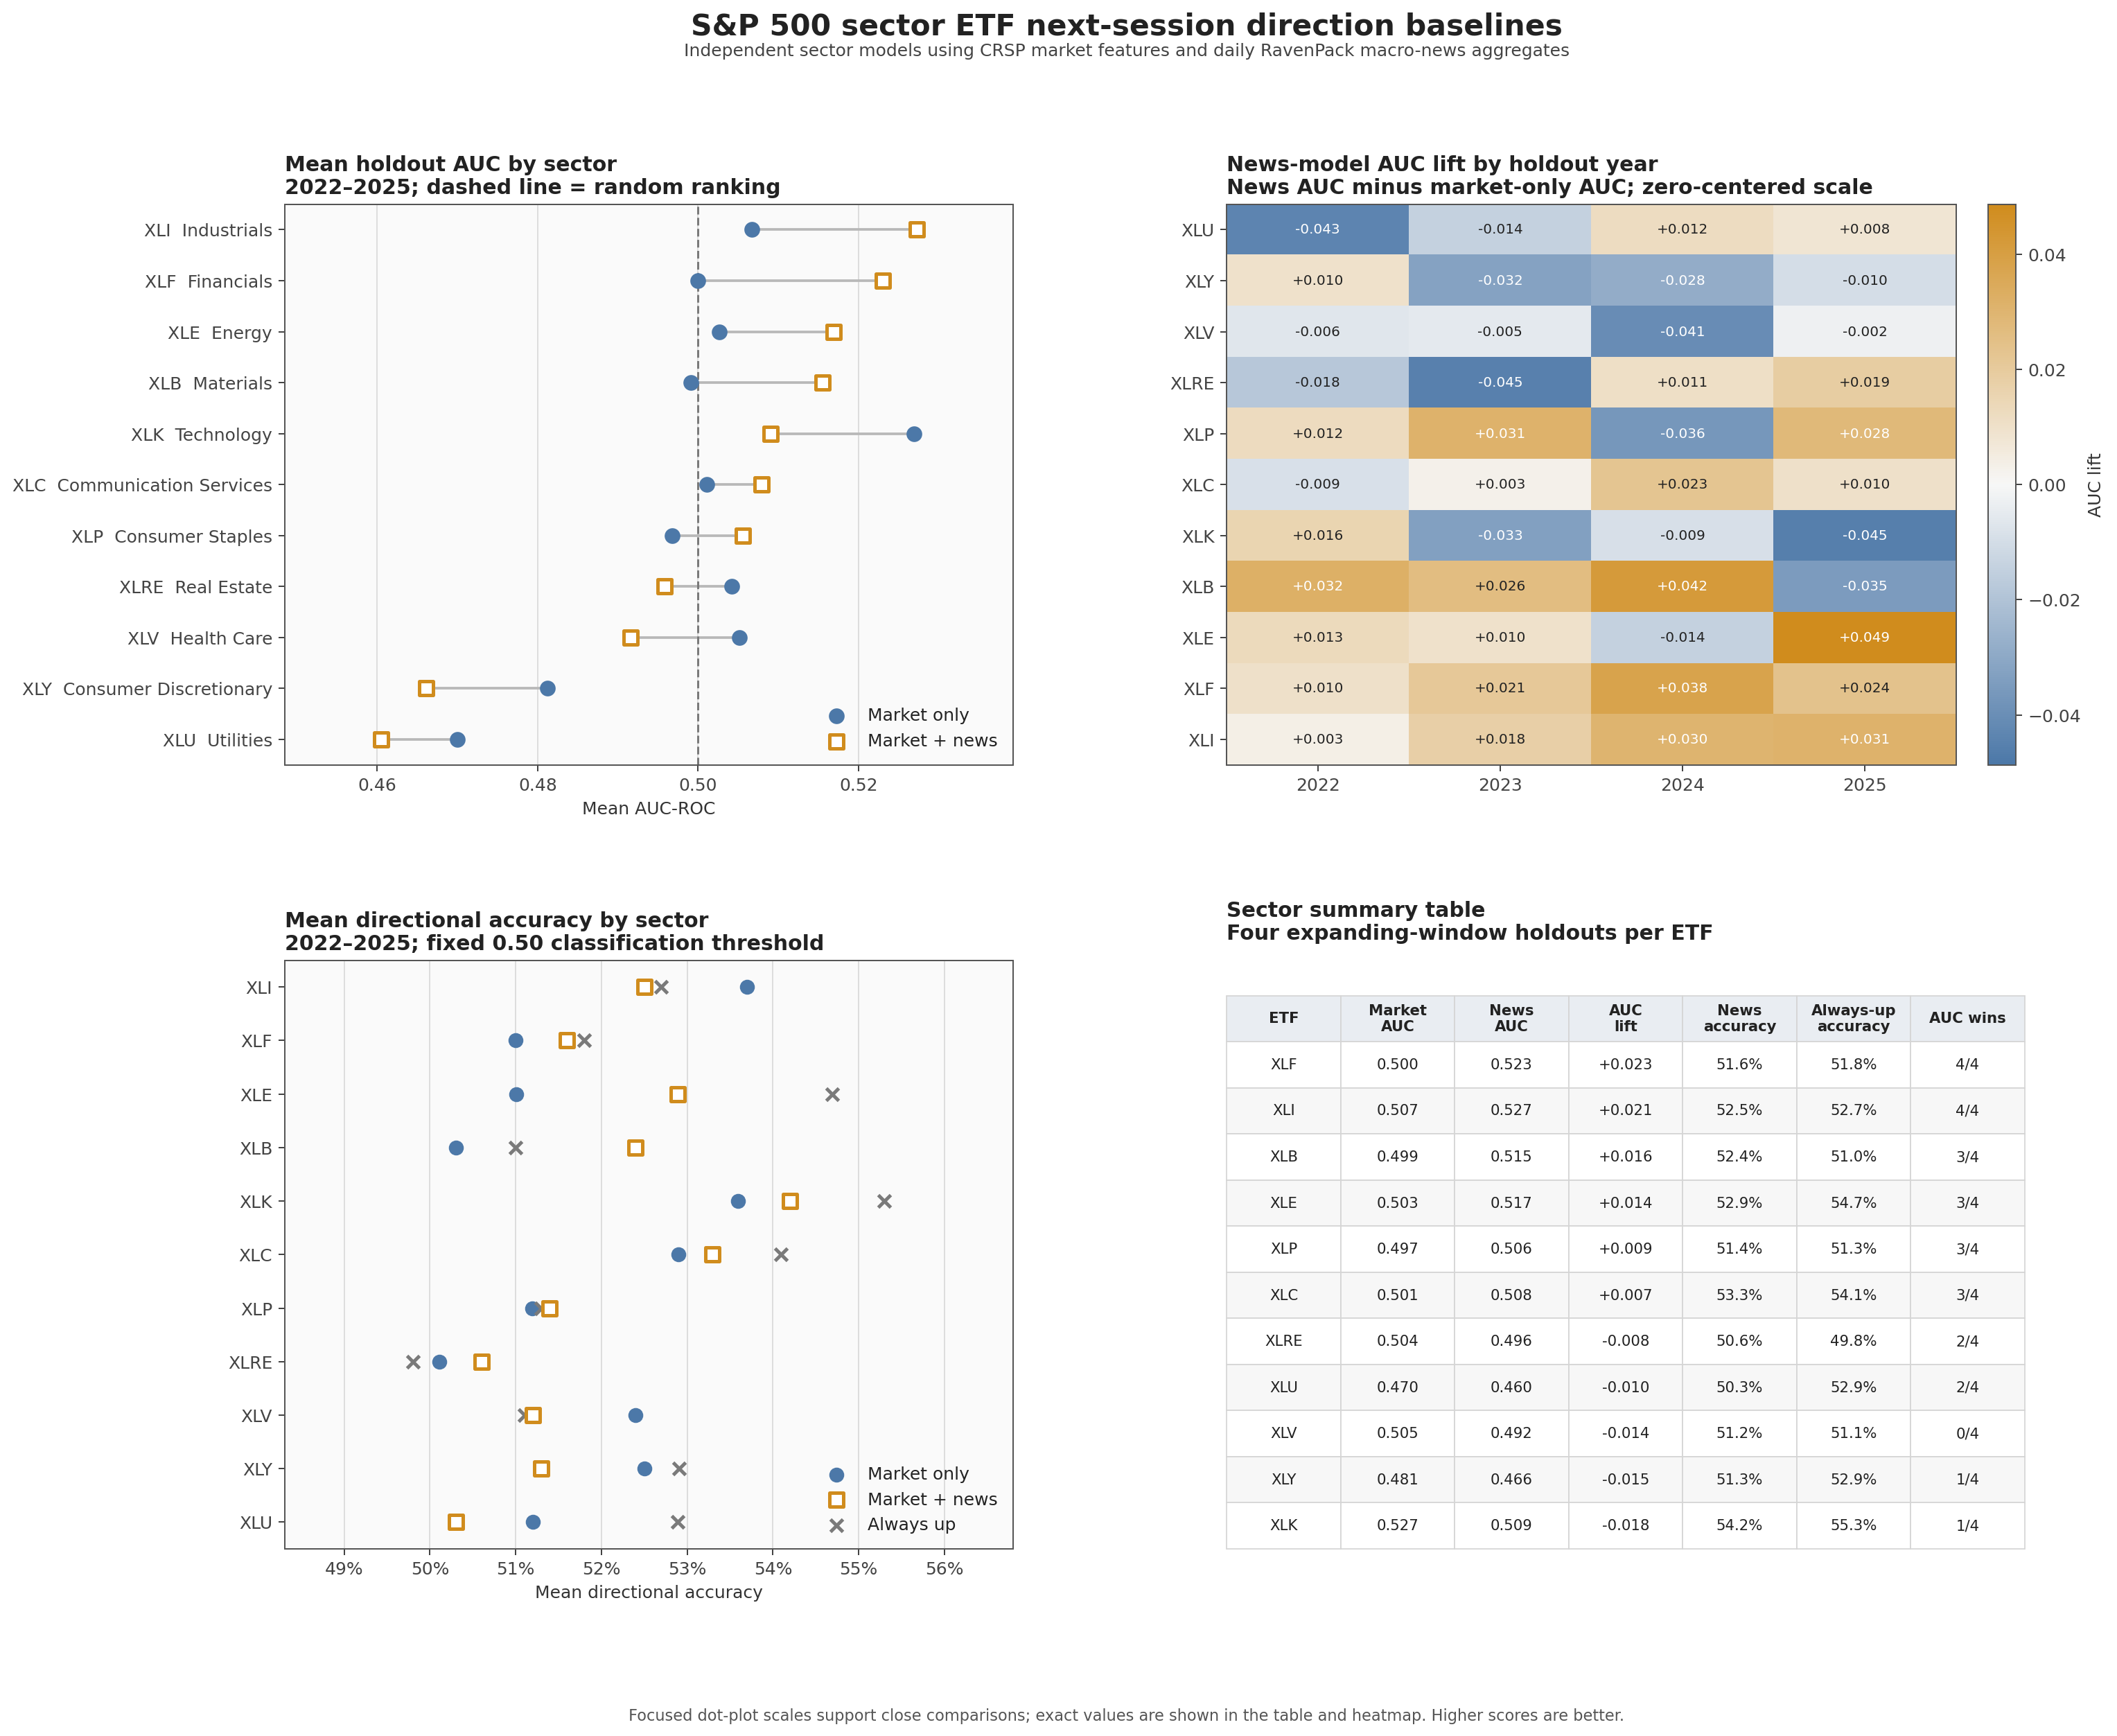

In [7]:
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "axes.edgecolor": "#555555",
        "axes.labelcolor": "#333333",
        "xtick.color": "#444444",
        "ytick.color": "#444444",
        "text.color": "#222222",
    }
)
MARKET_COLOR = "#4C78A8"
NEWS_COLOR = "#D08C1D"
REFERENCE_COLOR = "#7A7A7A"
GRID_COLOR = "#DDDDDD"
BACKGROUND = "#FAFAFA"

plot_order = sector_summary.sort_values(
    ["news_auc", "ticker"], ascending=[True, True]
).reset_index(drop=True)
y_positions = np.arange(len(plot_order))

fig = plt.figure(figsize=(18, 14), facecolor="white")
grid = fig.add_gridspec(
    2, 2, width_ratios=[1.05, 1.15], height_ratios=[1, 1.05],
    hspace=0.34, wspace=0.28,
)

# Panel A: mean AUC dot comparison.
auc_axis = fig.add_subplot(grid[0, 0])
auc_axis.set_facecolor(BACKGROUND)
for y, row in plot_order.iterrows():
    auc_axis.plot(
        [row["market_auc"], row["news_auc"]],
        [y, y],
        color="#B8B8B8",
        linewidth=1.5,
        zorder=1,
    )
auc_axis.scatter(
    plot_order["market_auc"], y_positions,
    s=65, color=MARKET_COLOR, marker="o",
    label="Market only", zorder=3,
)
auc_axis.scatter(
    plot_order["news_auc"], y_positions,
    s=70, facecolor="white", edgecolor=NEWS_COLOR, linewidth=2,
    marker="s", label="Market + news", zorder=4,
)
auc_axis.axvline(
    0.5, color=REFERENCE_COLOR, linestyle="--", linewidth=1.2,
)
auc_values = plot_order[["market_auc", "news_auc"]].to_numpy()
auc_padding = 0.012
auc_axis.set_xlim(
    min(0.5, float(auc_values.min())) - auc_padding,
    max(0.5, float(auc_values.max())) + auc_padding,
)
auc_axis.set_yticks(y_positions)
auc_axis.set_yticklabels(
    [f"{row.ticker}  {row.sector}" for row in plot_order.itertuples()]
)
auc_axis.set_xlabel("Mean AUC-ROC")
auc_axis.set_title(
    "Mean holdout AUC by sector\n2022–2025; dashed line = random ranking",
    loc="left", fontsize=12, fontweight="bold",
)
auc_axis.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
auc_axis.set_axisbelow(True)
auc_axis.legend(frameon=False, loc="lower right")

# Panel B: fold-level AUC lift heatmap.
heatmap_axis = fig.add_subplot(grid[0, 1])
lift_matrix = (
    fold_auc["auc_lift"].unstack("fold")
    .reindex(plot_order["ticker"])
    .loc[:, TEST_YEARS]
)
max_abs_lift = max(0.01, float(np.abs(lift_matrix.to_numpy()).max()))
lift_cmap = LinearSegmentedColormap.from_list(
    "blue_to_orange", [MARKET_COLOR, "#F7F7F7", NEWS_COLOR]
)
heat = heatmap_axis.imshow(
    lift_matrix.to_numpy(),
    aspect="auto",
    cmap=lift_cmap,
    vmin=-max_abs_lift,
    vmax=max_abs_lift,
)
heatmap_axis.set_xticks(np.arange(len(TEST_YEARS)))
heatmap_axis.set_xticklabels(TEST_YEARS)
heatmap_axis.set_yticks(np.arange(len(lift_matrix)))
heatmap_axis.set_yticklabels(lift_matrix.index)
heatmap_axis.set_title(
    "News-model AUC lift by holdout year\nNews AUC minus market-only AUC; zero-centered scale",
    loc="left", fontsize=12, fontweight="bold",
)
for row_index in range(lift_matrix.shape[0]):
    for column_index in range(lift_matrix.shape[1]):
        value = lift_matrix.iloc[row_index, column_index]
        text_color = (
            "white"
            if abs(value) > max_abs_lift * 0.55
            else "#222222"
        )
        heatmap_axis.text(
            column_index, row_index, f"{value:+.3f}",
            ha="center", va="center", fontsize=8, color=text_color,
        )
colorbar = fig.colorbar(
    heat, ax=heatmap_axis, fraction=0.046, pad=0.04
)
colorbar.set_label("AUC lift")

# Panel C: accuracy against the always-up reference.
accuracy_axis = fig.add_subplot(grid[1, 0])
accuracy_axis.set_facecolor(BACKGROUND)
accuracy_axis.scatter(
    plot_order["market_accuracy"], y_positions,
    s=58, color=MARKET_COLOR, marker="o",
    label="Market only", zorder=3,
)
accuracy_axis.scatter(
    plot_order["news_accuracy"], y_positions,
    s=65, facecolor="white", edgecolor=NEWS_COLOR, linewidth=2,
    marker="s", label="Market + news", zorder=4,
)
accuracy_axis.scatter(
    plot_order["reference_accuracy"], y_positions,
    s=52, color=REFERENCE_COLOR, marker="x", linewidth=2,
    label="Always up", zorder=3,
)
accuracy_values = plot_order[
    ["market_accuracy", "news_accuracy", "reference_accuracy"]
].to_numpy()
accuracy_axis.set_xlim(
    float(accuracy_values.min()) - 0.015,
    float(accuracy_values.max()) + 0.015,
)
accuracy_axis.set_yticks(y_positions)
accuracy_axis.set_yticklabels(plot_order["ticker"])
accuracy_axis.set_xlabel("Mean directional accuracy")
accuracy_axis.set_title(
    "Mean directional accuracy by sector\n2022–2025; fixed 0.50 classification threshold",
    loc="left", fontsize=12, fontweight="bold",
)
accuracy_axis.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda value, _: f"{value:.0%}")
)
accuracy_axis.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
accuracy_axis.set_axisbelow(True)
accuracy_axis.legend(frameon=False, loc="lower right")

# Panel D: exact lookup table.
table_axis = fig.add_subplot(grid[1, 1])
table_axis.axis("off")
table_axis.set_title(
    "Sector summary table\nFour expanding-window holdouts per ETF",
    loc="left", fontsize=12, fontweight="bold", pad=12,
)
table_rows = []
for row in sector_summary.itertuples(index=False):
    table_rows.append(
        [
            row.ticker,
            f"{row.market_auc:.3f}",
            f"{row.news_auc:.3f}",
            f"{row.auc_lift:+.3f}",
            f"{row.news_accuracy:.1%}",
            f"{row.reference_accuracy:.1%}",
            f"{row.news_auc_wins}/4",
        ]
    )
summary_table = table_axis.table(
    cellText=table_rows,
    colLabels=[
        "ETF", "Market\nAUC", "News\nAUC", "AUC\nlift",
        "News\naccuracy", "Always-up\naccuracy", "AUC wins",
    ],
    cellLoc="center",
    colLoc="center",
    bbox=[0, 0, 1, 0.94],
)
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(8.5)
for (row_index, column_index), cell in summary_table.get_celld().items():
    cell.set_edgecolor("#D5D5D5")
    cell.set_linewidth(0.7)
    if row_index == 0:
        cell.set_facecolor("#E9EDF2")
        cell.set_text_props(fontweight="bold", color="#222222")
    elif row_index % 2 == 0:
        cell.set_facecolor("#F7F7F7")
    else:
        cell.set_facecolor("white")

fig.suptitle(
    "S&P 500 sector ETF next-session direction baselines",
    fontsize=17, fontweight="bold", y=0.99,
)
fig.text(
    0.5, 0.965,
    "Independent sector models using CRSP market features and daily "
    "RavenPack macro-news aggregates",
    ha="center", fontsize=10, color="#444444",
)
fig.text(
    0.5, 0.012,
    "Focused dot-plot scales support close comparisons; exact values "
    "are shown in the table and heatmap. Higher scores are better.",
    ha="center", fontsize=9, color="#555555",
)
fig.savefig(FIGURE_PATH, dpi=180, bbox_inches="tight")
print(f"Saved {FIGURE_PATH.relative_to(REPO_ROOT)}")
plt.show()

## Takeaways

### 7. Report the executed cross-sector evidence

The code below derives the headline counts and averages directly from the saved summary. It avoids interpreting small descriptive differences as proof of stable predictive value.

In [8]:
sectors_with_positive_mean_auc_lift = int(
    sector_summary["auc_lift"].gt(0).sum()
)
sectors_beating_always_up = int(
    sector_summary["news_accuracy"]
    .gt(sector_summary["reference_accuracy"])
    .sum()
)
overall_market_auc = float(sector_summary["market_auc"].mean())
overall_news_auc = float(sector_summary["news_auc"].mean())
best_row = sector_summary.iloc[0]
worst_row = sector_summary.iloc[-1]

print("All-sector baseline interpretation")
print(
    f"- Mean AUC across sectors: market-only {overall_market_auc:.3f}; "
    f"market + news {overall_news_auc:.3f}; "
    f"change {overall_news_auc - overall_market_auc:+.3f}."
)
print(
    f"- Positive mean AUC lift appears in "
    f"{sectors_with_positive_mean_auc_lift} of "
    f"{len(SECTOR_TICKERS)} sectors."
)
print(
    f"- The news model beats each sector's always-up accuracy in "
    f"{sectors_beating_always_up} of {len(SECTOR_TICKERS)} sectors."
)
print(
    f"- Largest mean AUC lift: {best_row['ticker']} "
    f"{best_row['auc_lift']:+.3f}; smallest: "
    f"{worst_row['ticker']} {worst_row['auc_lift']:+.3f}."
)
print(
    "- These are descriptive out-of-sample comparisons, not "
    "statistical evidence of causality or profitability."
)

All-sector baseline interpretation
- Mean AUC across sectors: market-only 0.499; market + news 0.502; change +0.002.
- Positive mean AUC lift appears in 6 of 11 sectors.
- The news model beats each sector's always-up accuracy in 4 of 11 sectors.
- Largest mean AUC lift: XLF +0.023; smallest: XLK -0.018.
- These are descriptive out-of-sample comparisons, not statistical evidence of causality or profitability.


### Limitations and next step

The same daily macro-news features are shared across sectors, while only the lagged market features vary by ETF. The fitted models are linear, the classification threshold is fixed, and the four annual folds provide limited evidence about stability. A positive lift in one sector or year may therefore reflect sampling variation.

The next rigorous step is to replace or augment RavenPack's event sentiment with time-safe LLM-derived scores, pre-register the comparison metrics, and use paired uncertainty estimates across dates or folds. Any trading interpretation would additionally require transaction costs, turnover, and probability calibration.